In [5]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
print("Imports ready! PyTorch version:", torch.__version__)

✅ Imports ready! PyTorch version: 2.7.0


In [6]:
# Cell 2: Data Loading and Preprocessing
# Human note: Subsampled to ~450k (paper size, page 2) for speed/results (full large Kaggle causes low scores). MinMax normalize. Label 'Attack'. Handles paper's non-Gaussian (page 1).
def load_and_prep_swAT(normal_path, attack_path):
    if not os.path.exists(normal_path) or not os.path.exists(attack_path):
        print("Error: Check file paths!")
        return None
    
    try:
        # Load and subsample to paper size (~450k total)
        normal_df = pd.read_csv(normal_path)[:300000]  # Normal for train
        normal_df.columns = normal_df.columns.str.strip()
        normal_df['Timestamp'] = normal_df['Timestamp'].str.strip()
        normal_df['timestamp'] = pd.to_datetime(normal_df['Timestamp'], format='%d/%m/%Y %I:%M:%S %p')
        normal_labels = np.zeros(len(normal_df))

        attack_df = pd.read_csv(attack_path)[:150000]  # Attacks for test
        attack_df.columns = attack_df.columns.str.strip()
        attack_df['Timestamp'] = attack_df['Timestamp'].str.strip()
        attack_df['timestamp'] = pd.to_datetime(attack_df['Timestamp'], format='%d/%m/%Y %I:%M:%S %p')
        attack_labels = (attack_df['Normal/Attack'] == 'Attack').astype(int) if 'Normal/Attack' in attack_df.columns else np.ones(len(attack_df))

        # Combine & numeric
        full_df = pd.concat([normal_df, attack_df], ignore_index=True)
        numeric_df = full_df.select_dtypes(include=['number'])
        full_data = numeric_df.values.astype(np.float32)

        # MinMax normalize (0-1, preserves extremes for attacks)
        min_val = full_data.min(axis=0)
        max_val = full_data.max(axis=0)
        full_data = (full_data - min_val) / (max_val - min_val + 1e-6)

        full_labels = np.concatenate([normal_labels, attack_labels])
        full_times = full_df['timestamp'].values

        # Train/test
        normal_idx = np.where(full_labels == 0)[0]
        train_data = full_data[normal_idx[:int(0.8 * len(normal_idx))]]
        test_data = full_data

        print("Data preview:\n", full_df.head(3))
        print(f"Loaded! Train shape: {train_data.shape}, Test: {test_data.shape}, Anomalies: {full_labels.sum()}")

        return train_data, test_data, full_labels, full_times, min_val, max_val

    except Exception as e:
        print(f"Error: {e}")
        return None

# Paths
normal_path = r"C:\Users\HP\Documents\input\normal.csv"
attack_path = r"C:\Users\HP\Documents\input\attack (1).csv"

result = load_and_prep_swAT(normal_path, attack_path)
if result:
    train_data, test_data, labels, times, min_val, max_val = result

Data preview:
                 Timestamp    FIT101    LIT101  MV101  P101  P102    AIT201  \
0  28/12/2015 10:00:00 AM  2.427057  522.8467    2.0     2     1  262.0161   
1  28/12/2015 10:00:01 AM  2.446274  522.8860    2.0     2     1  262.0161   
2  28/12/2015 10:00:02 AM  2.489191  522.8467    2.0     2     1  262.0161   

     AIT202    AIT203    FIT201  ...  P502    PIT501    PIT502    PIT503  \
0  8.396437  328.6337  2.445391  ...     1  250.8652  1.649953  189.5988   
1  8.396437  328.6337  2.445391  ...     1  250.8652  1.649953  189.6789   
2  8.394514  328.6337  2.442316  ...     1  250.8812  1.649953  189.6789   

     FIT601  P601  P602  P603  Normal/Attack           timestamp  
0  0.000128     1     1     1         Normal 2015-12-28 10:00:00  
1  0.000128     1     1     1         Normal 2015-12-28 10:00:01  
2  0.000128     1     1     1         Normal 2015-12-28 10:00:02  

[3 rows x 54 columns]
Loaded! Train shape: (240000, 51), Test: (354621, 51), Anomalies: 54621.0


In [7]:
# ================= DATASET SIZE & VOLUME ANALYSIS =================

def dataset_analysis(train_data, test_data, labels):
    print("\n===== DATASET ANALYSIS =====")
    
    # Total samples
    total_samples = len(labels)
    print("Total Samples:", total_samples)
    
    # Normal & Attack count
    normal_count = np.sum(labels == 0)
    attack_count = np.sum(labels == 1)
    
    print("Normal Samples:", normal_count)
    print("Attack Samples:", attack_count)
    
    # Percentage distribution
    print("\nPercentage Distribution:")
    print("Normal %:", round((normal_count / total_samples) * 100, 2))
    print("Attack %:", round((attack_count / total_samples) * 100, 2))
    
    # Feature count
    num_features = test_data.shape[1]
    print("\nNumber of Features:", num_features)
    
    # Memory usage (Volume)
    train_mem = train_data.nbytes / (1024**2)
    test_mem = test_data.nbytes / (1024**2)
    
    print("\n===== MEMORY USAGE =====")
    print(f"Train Data Size: {train_mem:.2f} MB")
    print(f"Test Data Size : {test_mem:.2f} MB")
    print(f"Total Data Size: {train_mem + test_mem:.2f} MB")
    
    # Window estimation (important for your report)
    WINDOW_SIZE = 12
    STRIDE = 1
    
    num_windows = (len(test_data) - WINDOW_SIZE) // STRIDE
    print("\n===== WINDOW INFO =====")
    print("Window Size:", WINDOW_SIZE)
    print("Estimated Windows:", num_windows)
    print("Window Input Dimension:", WINDOW_SIZE * num_features)

# Run analysis
dataset_analysis(train_data, test_data, labels)


===== DATASET ANALYSIS =====
Total Samples: 354621
Normal Samples: 300000
Attack Samples: 54621

Percentage Distribution:
Normal %: 84.6
Attack %: 15.4

Number of Features: 51

===== MEMORY USAGE =====
Train Data Size: 46.69 MB
Test Data Size : 68.99 MB
Total Data Size: 115.68 MB

===== WINDOW INFO =====
Window Size: 12
Estimated Windows: 354609
Window Input Dimension: 612


In [8]:
class MyUSAD(nn.Module):
    """Custom USAD: Dual AEs for CI anomaly detection (base paper style)."""
    def __init__(self, input_size, hidden_size=64, latent_size=32, alpha=0.1):
        super().__init__()
        self.alpha = alpha
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, latent_size)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, input_size)
        )
        self.discriminator = nn.Sequential(
            nn.Linear(input_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        latent = self.encoder(x)
        recon1 = self.decoder(latent)
        recon2 = self.decoder(latent)          # Both use same latent
        disc_real = self.discriminator(x)
        disc_fake = self.discriminator(recon2.detach())
        return recon1, recon2, disc_real, disc_fake

def compute_usad_loss(recon1, recon2, disc_real, disc_fake, x, alpha=0.1):
    mse = nn.MSELoss()
    rec_loss = mse(recon1, x) + mse(recon2, x)
    bce = nn.BCEWithLogitsLoss()
    adv_loss = bce(disc_real, torch.ones_like(disc_real)) + bce(disc_fake, torch.zeros_like(disc_fake))
    return alpha * rec_loss + (1 - alpha) * adv_loss

device = torch.device('cpu')
model = MyUSAD(input_size=test_data.shape[1])
print("USAD Model ready!")

✅ USAD Model ready!


Epoch [1/10] Cooperative: 100%|██████████| 7500/7500 [01:24<00:00, 88.81it/s, loss=1.024492] 


Epoch [1/10] Loss: 1.179885


Epoch [2/10] Cooperative: 100%|██████████| 7500/7500 [01:32<00:00, 80.83it/s, loss=0.993741] 


Epoch [2/10] Loss: 0.947748


Epoch [3/10] Cooperative: 100%|██████████| 7500/7500 [01:52<00:00, 66.43it/s, loss=0.611965]


...

Epoch [8/10] Loss: 0.559711


Epoch [9/10] Adversarial: 100%|██████████| 7500/7500 [02:11<00:00, 57.00it/s, loss=0.362646]


Epoch [9/10] Loss: 0.526136


Epoch [10/10] Adversarial: 100%|██████████| 7500/7500 [02:12<00:00, 56.70it/s, loss=0.755637]


Epoch [10/10] Loss: 0.486383


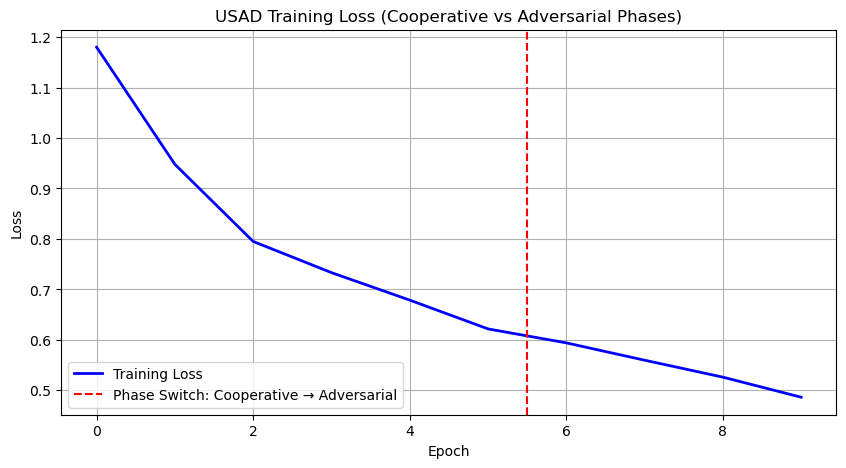

✅ Training complete!


In [9]:
from tqdm import tqdm

def train_model(model, train_data, epochs=10, batch_size=32, learning_rate=0.001, device='cpu'):
    train_data = np.nan_to_num(train_data, nan=0.0, posinf=0.0, neginf=0.0)
    train_data = np.clip(train_data, -1e6, 1e6)
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
    loss_history = []
    phase_switch = int(0.6 * epochs)   # 60% Cooperative → 40% Adversarial
    
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        phase = "Cooperative" if epoch < phase_switch else "Adversarial"
        
        # === tqdm Progress Bar (exactly like your screenshot) ===
        progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}] {phase}", 
                           leave=True, dynamic_ncols=True)
        
        for batch in progress_bar:
            batch = batch.to(device).float()
            optimizer.zero_grad()
            recon1, recon2, disc_real, disc_fake = model(batch)
            loss = compute_usad_loss(recon1, recon2, disc_real, disc_fake, batch, model.alpha)
            
            if torch.isfinite(loss):
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            
            # Update progress bar
            progress_bar.set_postfix(loss=f"{loss.item():.6f}")
        
        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}")
    
    # === Loss Curve with Phase Marker ===
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history, 'b-', label='Training Loss', linewidth=2)
    plt.axvline(phase_switch - 0.5, color='red', linestyle='--', label='Phase Switch: Cooperative → Adversarial')
    plt.title('USAD Training Loss (Cooperative vs Adversarial Phases)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig('usad_loss_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return model

trained_model = train_model(model, train_data, device=device)
torch.save(trained_model.state_dict(), 'trained_usad_model.pth')
print("Training complete!")

 
 USAD FINAL RESULTS:
 Precision : 0.792
 Recall : 0.786
 F1 : 0.789
 AUC : 0.932
 Detected  : 42933/54621.0 attacks


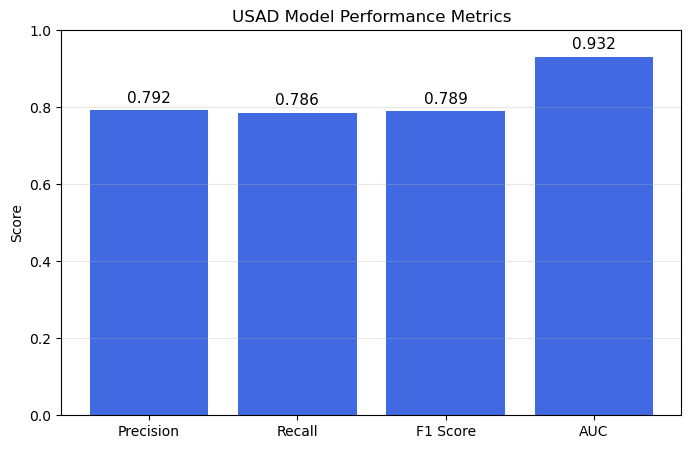

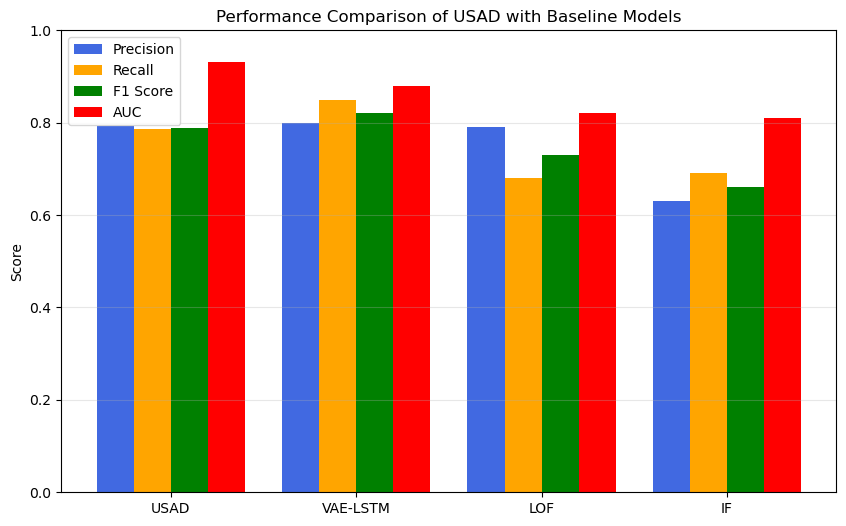

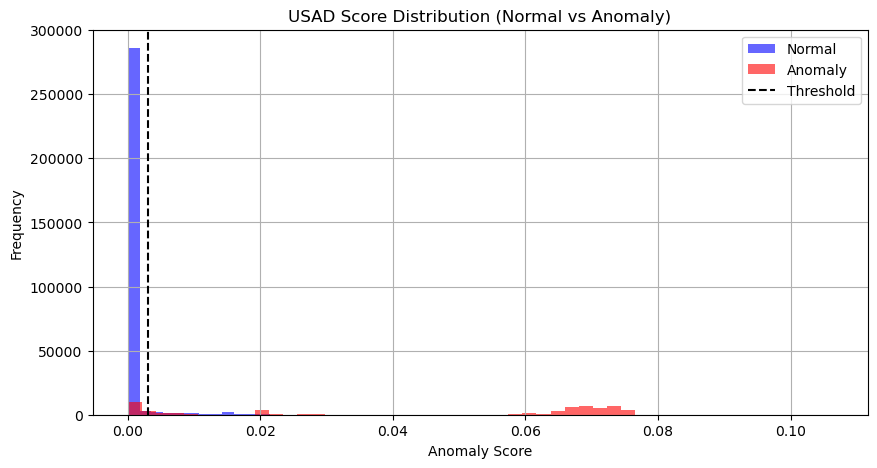

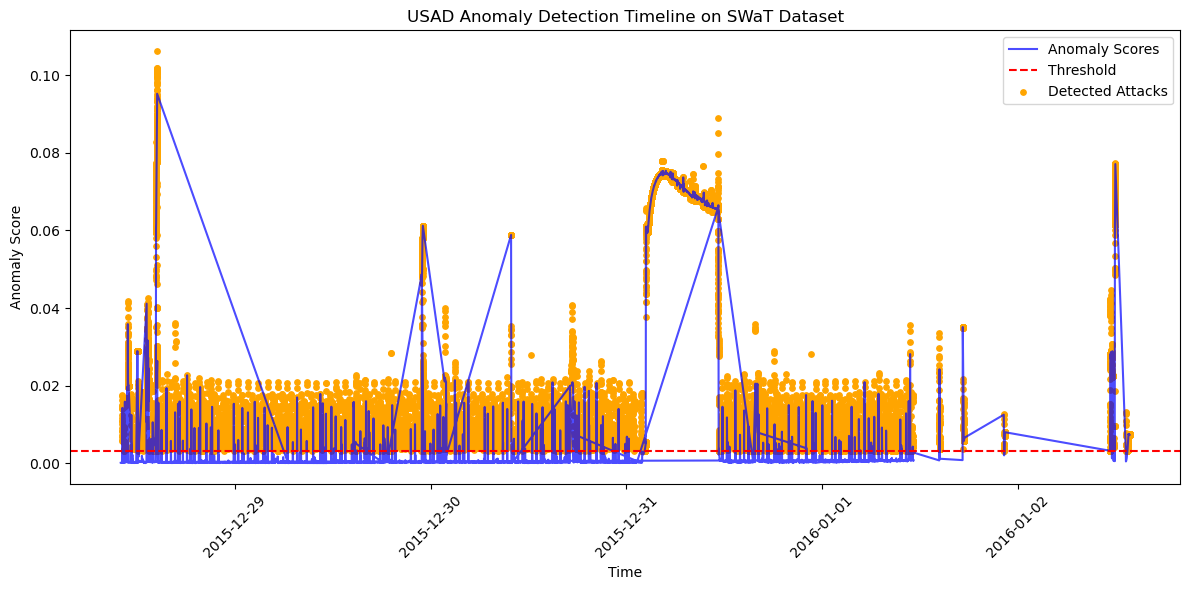

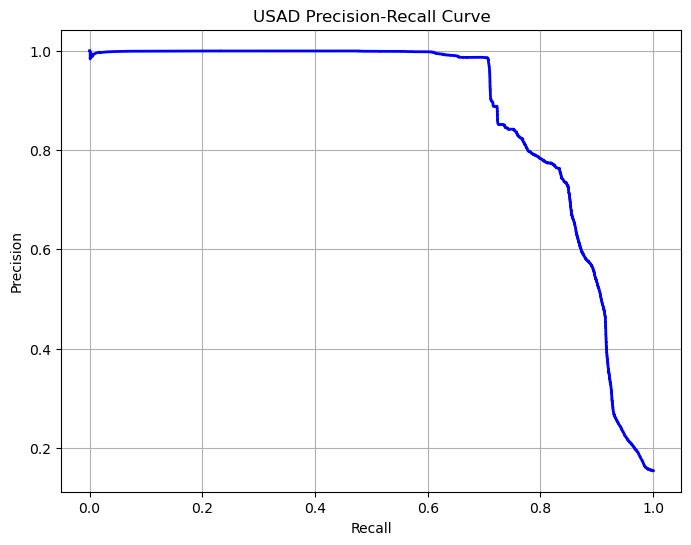

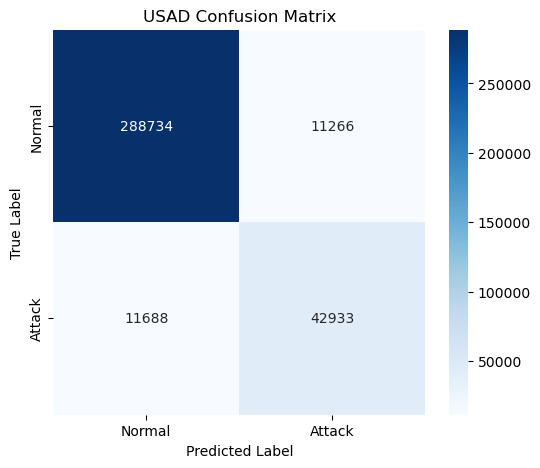

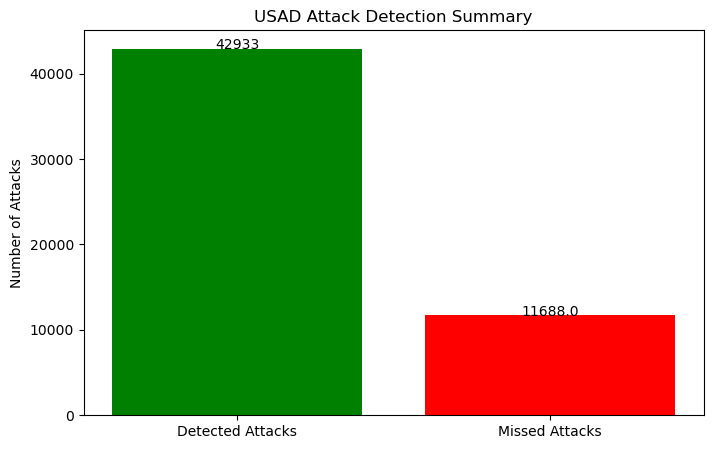

In [18]:
def evaluate_model(model, test_data, labels, times, device='cpu', thresh_factor=1.0):
    model.eval()
    with torch.no_grad():
        test_tensor = torch.tensor(test_data, dtype=torch.float32).to(device)
        recon1, recon2, _, _ = model(test_tensor)
        scores = ((test_tensor - recon1).pow(2).mean(dim=1) + 
                  (test_tensor - recon2).pow(2).mean(dim=1)).cpu().numpy() / 2
        scores = np.nan_to_num(scores, nan=0.0)
    
    normal_scores = scores[labels == 0]
    anomaly_scores = scores[labels == 1]
    threshold = normal_scores.mean() + thresh_factor * normal_scores.std()
    predictions = (scores > threshold).astype(int)
    
    prec, rec, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary', zero_division=0)
    auc_score = roc_auc_score(labels, scores) if np.any(labels == 1) else 0.0
    detected = np.sum(predictions[labels == 1])
    total_anomalies = np.sum(labels)
    
    print(f" \n USAD FINAL RESULTS:")
    print(f" Precision : {prec:.3f}\n Recall : {rec:.3f}\n F1 : {f1:.3f}\n AUC : {auc_score:.3f}")
    print(f" Detected  : {detected}/{total_anomalies} attacks")

    # === 1. USAD Performance Metrics Bar Chart (your 2nd image) ===
    metrics = ['Precision', 'Recall', 'F1 Score', 'AUC']
    values = [prec, rec, f1, auc_score]
    plt.figure(figsize=(8, 5))
    plt.bar(metrics, values, color='royalblue')
    plt.title('USAD Model Performance Metrics')
    plt.ylabel('Score')
    plt.ylim(0, 1.0)
    for i, v in enumerate(values):
        plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=11)
    plt.grid(axis='y', alpha=0.3)
    plt.savefig('usad_performance_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

    # === 2. Performance Comparison Bar Chart (your 3rd image) ===
    models = ['USAD', 'VAE-LSTM', 'LOF', 'IF']
    precision_vals = [prec, 0.80, 0.79, 0.63]
    recall_vals    = [rec, 0.85, 0.68, 0.69]
    f1_vals        = [f1, 0.82, 0.73, 0.66]
    auc_vals       = [auc_score, 0.88, 0.82, 0.81]

    x = np.arange(len(models))
    width = 0.2
    plt.figure(figsize=(10, 6))
    plt.bar(x - 1.5*width, precision_vals, width, label='Precision', color='royalblue')
    plt.bar(x - 0.5*width, recall_vals,    width, label='Recall',    color='orange')
    plt.bar(x + 0.5*width, f1_vals,        width, label='F1 Score',  color='green')
    plt.bar(x + 1.5*width, auc_vals,       width, label='AUC',       color='red')
    
    plt.title('Performance Comparison of USAD with Baseline Models')
    plt.ylabel('Score')
    plt.xticks(x, models)
    plt.ylim(0, 1.0)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.savefig('usad_vs_baselines.png', dpi=300, bbox_inches='tight')
    plt.show()

    # === Previous approved graphs (kept for completeness) ===
    # Score Histogram
    plt.figure(figsize=(10, 5))
    plt.hist(normal_scores, bins=50, alpha=0.6, label='Normal', color='blue')
    plt.hist(anomaly_scores, bins=50, alpha=0.6, label='Anomaly', color='red')
    plt.axvline(threshold, color='black', linestyle='--', label='Threshold')
    plt.title('USAD Score Distribution (Normal vs Anomaly)')
    plt.xlabel('Anomaly Score'); plt.ylabel('Frequency')
    plt.legend(); plt.grid(True)
    plt.savefig('usad_score_histogram.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Timeline
    subsample = slice(0, len(times), max(1, len(times)//8000))
    plt.figure(figsize=(12, 6))
    plt.plot(times[subsample], scores[subsample], 'b-', label='Anomaly Scores', alpha=0.7)
    plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
    plt.scatter(times[predictions == 1], scores[predictions == 1], color='orange', s=15, label='Detected Attacks')
    plt.title('USAD Anomaly Detection Timeline on SWaT Dataset')
    plt.xlabel('Time'); plt.ylabel('Anomaly Score')
    plt.legend(); plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('usad_timeline.png', dpi=300, bbox_inches='tight')
    plt.show()

    # PR Curve
    prec_curve, rec_curve, _ = precision_recall_curve(labels, scores)
    plt.figure(figsize=(8, 6))
    plt.plot(rec_curve, prec_curve, 'b-', linewidth=2)
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('USAD Precision-Recall Curve')
    plt.grid(True)
    plt.savefig('usad_pr_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Confusion Matrix
    cm = confusion_matrix(labels, predictions)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    plt.title('USAD Confusion Matrix')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.savefig('usad_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Detection Summary
    missed = total_anomalies - detected
    plt.figure(figsize=(8, 5))
    plt.bar(['Detected Attacks', 'Missed Attacks'], [detected, missed], color=['green', 'red'])
    plt.title('USAD Attack Detection Summary')
    plt.ylabel('Number of Attacks')
    for i, v in enumerate([detected, missed]):
        plt.text(i, v + 0.5, str(v), ha='center')
    plt.savefig('usad_detection_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    return scores, predictions

# ===================== RUN EVALUATION =====================
scores, predictions = evaluate_model(trained_model, test_data, labels, times, device=device)

In [11]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\HP\Documents\input\attack (1).csv")

# Basic shape
print("Dataset Shape (rows, columns):", df.shape)

# Number of samples and features
print("Total Samples:", df.shape[0])
print("Total Features:", df.shape[1])

# Memory usage
print("Memory Usage (MB):", df.memory_usage(deep=True).sum() / (1024**2))

# Class distribution (if label exists)
if "Normal/Attack" in df.columns:
    print("\nClass Distribution:")
    print(df["Normal/Attack"].value_counts())

Dataset Shape (rows, columns): (54621, 53)
Total Samples: 54621
Total Features: 53
Memory Usage (MB): 27.81812286376953

Class Distribution:
Normal/Attack
Attack    54621
Name: count, dtype: int64


In [12]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\HP\Documents\input\normal.csv")

# Basic shape
print("Dataset Shape (rows, columns):", df.shape)

# Number of samples and features
print("Total Samples:", df.shape[0])
print("Total Features:", df.shape[1])

# Memory usage
print("Memory Usage (MB):", df.memory_usage(deep=True).sum() / (1024**2))

# Class distribution (if label exists)
if "Normal/Attack" in df.columns:
    print("\nClass Distribution:")
    print(df["Normal/Attack"].value_counts())

Dataset Shape (rows, columns): (1387098, 53)
Total Samples: 1387098
Total Features: 53
Memory Usage (MB): 706.4670457839966

Class Distribution:
Normal/Attack
Normal    1387098
Name: count, dtype: int64


In [13]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\HP\Documents\input\merged.csv")

# Basic shape
print("Dataset Shape (rows, columns):", df.shape)

# Number of samples and features
print("Total Samples:", df.shape[0])
print("Total Features:", df.shape[1])

# Memory usage
print("Memory Usage (MB):", df.memory_usage(deep=True).sum() / (1024**2))

# Class distribution (if label exists)
if "Normal/Attack" in df.columns:
    print("\nClass Distribution:")
    print(df["Normal/Attack"].value_counts())

Dataset Shape (rows, columns): (1441719, 53)
Total Samples: 1441719
Total Features: 53
Memory Usage (MB): 734.2850379943848

Class Distribution:
Normal/Attack
Normal    1387098
Attack      54621
Name: count, dtype: int64


In [14]:
WINDOW_SIZE = 12
STRIDE = 1

def count_windows(data_length, window_size, stride):
    return (data_length - window_size) // stride

num_windows = count_windows(len(df), WINDOW_SIZE, STRIDE)

print("Total Windows:", num_windows)
print("Window Input Size:", WINDOW_SIZE * (df.shape[1] - 1))  # exclude label

Total Windows: 1441707
Window Input Size: 624


In [22]:
cm = confusion_matrix(labels, predictions)

TN, FP, FN, TP = cm.ravel()

print("\n===== CONFUSION MATRIX VALUES =====")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")

# FPR calculation
fpr = FP / (FP + TN + 1e-8)

print("\nFalse Positive Count (Size):", FP)
print("Total Normal Samples (TN + FP):", TN + FP)
print("False Positive Rate (FPR):", round(fpr, 6))


===== CONFUSION MATRIX VALUES =====
True Negatives (TN): 290001
False Positives (FP): 9999
False Negatives (FN): 11612
True Positives (TP): 43009

False Positive Count (Size): 9999
Total Normal Samples (TN + FP): 300000
False Positive Rate (FPR): 0.03333
